In [4]:

from google.colab import files
uploaded = files.upload()  # upload kaggle.json

import os, shutil
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
shutil.move("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [5]:
!mkdir -p fraud_data
!kaggle datasets download -d kartik2112/fraud-detection -p fraud_data --force
!unzip -o fraud_data/fraud-detection.zip -d fraud_data

Dataset URL: https://www.kaggle.com/datasets/kartik2112/fraud-detection
License(s): CC0-1.0
 54% 109M/202M [00:00<00:00, 1.12GB/s]
100% 202M/202M [00:00<00:00, 591MB/s] 
Archive:  fraud_data/fraud-detection.zip
  inflating: fraud_data/fraudTest.csv  
  inflating: fraud_data/fraudTrain.csv  


In [6]:
import pandas as pd

df = pd.read_csv("fraud_data/fraudTrain.csv")
print("Dataset shape:", df.shape)

Dataset shape: (1296675, 23)


In [7]:
drop_cols = [
    'is_fraud','Unnamed: 0','cc_num','trans_date_trans_time',
    'merchant','category','first','last','gender','street',
    'job','dob','trans_num','city','state','zip'
]

X = df.drop(columns=drop_cols)
y = df['is_fraud']

print("Features used:", list(X.columns))

Features used: ['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = model

    print(classification_report(y_test, y_pred, digits=4))
    print("ROC-AUC:", round(roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]), 4))


Training Logistic Regression...
              precision    recall  f1-score   support

           0     0.9985    0.9528    0.9751    257834
           1     0.0858    0.7615    0.1542      1501

    accuracy                         0.9517    259335
   macro avg     0.5422    0.8571    0.5647    259335
weighted avg     0.9933    0.9517    0.9704    259335

ROC-AUC: 0.8373

Training Decision Tree...
              precision    recall  f1-score   support

           0     0.9964    0.9969    0.9966    257834
           1     0.4121    0.3731    0.3916      1501

    accuracy                         0.9933    259335
   macro avg     0.7042    0.6850    0.6941    259335
weighted avg     0.9930    0.9933    0.9931    259335

ROC-AUC: 0.685

Training Random Forest...
              precision    recall  f1-score   support

           0     0.9966    0.9997    0.9981    257834
           1     0.8821    0.4137    0.5633      1501

    accuracy                         0.9963    259335
   macro a

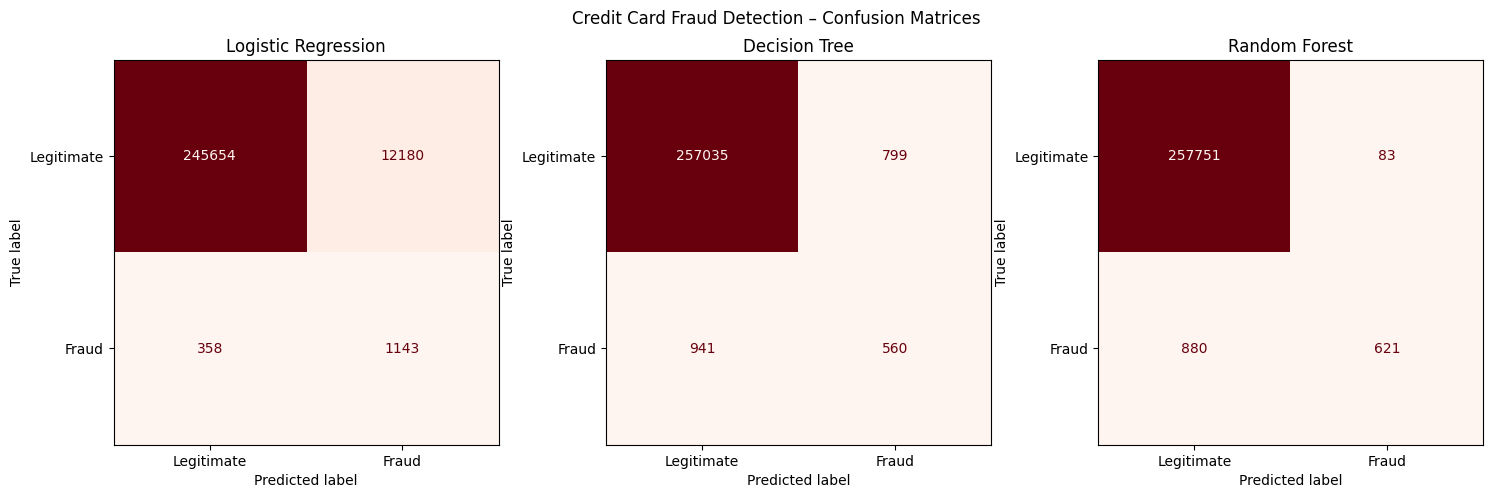

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, results.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legitimate", "Fraud"])
    disp.plot(ax=ax, cmap="Reds", colorbar=False)
    ax.set_title(name)

plt.suptitle("Credit Card Fraud Detection – Confusion Matrices")
plt.show()

In [11]:
# STEP 8: Test Your Own Transaction (FINAL & FIXED)

print("\n[STEP 8] Test Your Own Transaction")
print("Type 'exit' to stop\n")
print("Enter values in this order:")
print(list(X.columns))

while True:
    user_input = input("\nEnter transaction details separated by comma or 'exit': ")

    if user_input.lower() == "exit":
        print("Exiting interactive testing.")
        break

    try:
        values = list(map(float, user_input.split(",")))

        if len(values) != len(X.columns):
            print(f"⚠️ Please enter exactly {len(X.columns)} values.")
            continue

        input_df = pd.DataFrame([values], columns=X.columns)

        for name, model in results.items():
            pred = model.predict(input_df)[0]
            prob = model.predict_proba(input_df)[0][1]

            print(f"\n{name}:")
            print("Prediction:", "FRAUD 🚨" if pred == 1 else "LEGITIMATE ✅")
            print(f"Fraud Probability: {prob*100:.2f}%")

        print("-" * 60)

    except ValueError:
        print("⚠️ Invalid input. Enter numeric values only.")


[STEP 8] Test Your Own Transaction
Type 'exit' to stop

Enter values in this order:
['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']

Enter transaction details separated by comma or 'exit': 120.75,17.3850,78.4867,2500000,1672531200,17.4123,78.4506

Logistic Regression:
Prediction: LEGITIMATE ✅
Fraud Probability: 27.47%

Decision Tree:
Prediction: LEGITIMATE ✅
Fraud Probability: 0.00%

Random Forest:
Prediction: LEGITIMATE ✅
Fraud Probability: 1.00%
------------------------------------------------------------

Enter transaction details separated by comma or 'exit': 15.50,12.9716,77.5946,8500000,1672600000,12.9720,77.5950

Logistic Regression:
Prediction: LEGITIMATE ✅
Fraud Probability: 13.40%

Decision Tree:
Prediction: LEGITIMATE ✅
Fraud Probability: 0.00%

Random Forest:
Prediction: LEGITIMATE ✅
Fraud Probability: 0.00%
------------------------------------------------------------

Enter transaction details separated by comma or 'exit': 9876.45,28.7041,77.102